In [1]:
import os
import matplotlib.pyplot as plt
from pathlib import Path

## UNCOMMENT FOR DEV ENVIRONMENT
import sys
sys.path.insert(0,"/g/data/gb02/ab8992/regional-mom6/dev/mom6_forge")
sys.path.insert(0,"/g/data/gb02/ab8992/regional-mom6/dev/regional-mom6")

import regional_mom6 as rmom6
print("using regional-mom6 version " + rmom6.__version__)
print("If it prints with a git hash, you're successfully using a deployed rmom6 instance. If 'unknown', you're on local dev copy") 


expt_name = "nino-25th"
project = os.environ["PROJECT"]
user = os.environ["USER"]
scratch = Path(f"/g/data/{project}/{user}")
gdata = Path(f"/g/data/{project}/{user}")

## Place where all the input files go
input_dir = f"{gdata}/rom3-inputdirs/{expt_name}/"

## Directory where we'll be running the experiment from
run_dir = f"{gdata}/rom3-rundirs/{expt_name}/"

## Directory for temporary files we don't need long term, like the raw GLORYs downloads
tmp_dir = f"{scratch}/tmp/{expt_name}"

## if directories don't exist, create them
for path in (run_dir, tmp_dir, input_dir):
    os.makedirs(str(path), exist_ok=True)

using regional-mom6 version unknown
If it prints with a git hash, you're successfully using a deployed rmom6 instance. If 'unknown', you're on local dev copy


89.92 9.92
dy in km
4448
dx mean, dx max, dx min
4442	4431	4448


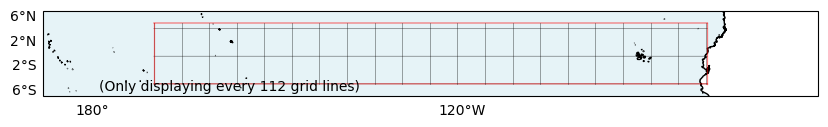

In [2]:
def make_bounds(delta,target_extent):
    """
    The uniform spherical grid from mom6 forge doesn't respect the resolution you give it if your resolution doesn't evenly divide the domain length
    Further, the UM requires even number of points.

    This function takes the target grid extent for your domain, respects the southwestern corner, and then sets the northwestern corner
    via the lenx/leny ensuring that npoints * delta = length exactly, and npoints is even. 
    """
    npoints = 1
    length = round(abs(target_extent[1] - target_extent[0]),5)
    length -= length % delta
    npoints = int(length / delta) # This may be an odd number. If so, subtract one point 
    if npoints % 2 != 0:
        length -= delta
        npoints = int(length / delta)

    return round(length,5)




dx = 1/25
dy = 1/25
target_lon_extent = [190, 280]
target_lat_extent = [-5,5]
lenx = make_bounds(dx,target_lon_extent)
leny = make_bounds(dy,target_lat_extent)

print(lenx,leny)

grid = rmom6.Grid(
    lenx = lenx,
    leny = leny,
    xstart = target_lon_extent[0],
    ystart = target_lat_extent[0],
    resolution_lon = dx,
    resolution_lat = dy
    )

if grid.tlon.shape[0]%2 != 0 or grid.tlon.shape[1]%2 != 0:
    print(grid.tlon.shape)
    raise ValueError("Ensure that both dimensions of grid are even. This is a UM requirement")

print("dy in km")
print(round(grid.dyCu.values.min()))

print("dx mean, dx max, dx min")
print(round(grid.dxCu.values.mean()),round(grid.dxCu.values.min()),round(grid.dxCu.values.max()),sep = "\t")

fig = grid.plot()
fig.set_size_inches((10,3))

In [3]:
expt = rmom6.experiment(              
    date_range = ["2008-01-01", "2013-01-30"],      # This will set the start date of the experiment, and ensure we download the right forcing data 
    hgrid_type=grid,                                # Type of horizontal grid. Even spacing is the default - check out documentation and other demos for more information about grids.
    number_vertical_layers = 100,                   # Number of vertical layers, not number of interfaces.
    layer_thickness_ratio = 150,                    # Ratio of the deepest layer thickness to the surface layer. Set higher for more resolution near the surface. Negative values mean there's higher resolution at the sea floor
    depth = 5500,                                   # Maximum depth of your domain. This will set the depth of the deepest layer in the vertical coordinate. Best to have this match the deepest point in your bathymetry, but it doesn't have to.
    minimum_depth = 5,                              # Minimum depth of your domain. Shallower water will be considered land and masked out.
    tidal_constituents=[],                          # You can put your favourite tidal consituents here (e.g. "M2") or remove this line to turn on all of them (the default behaviour)
    mom_run_dir = run_dir,                          # This is the directory from which you will run your experiment. Namelists and other text files go here
    mom_input_dir = input_dir,                      # The location for all the data files needed for your experiment. netcdfs go here. 
    boundaries=["north", "south", "east", "west"]   # The boundaries and their orientations. Rectangular domains are easiest, but see documentation and other demos to see how to set up more complex domains
)

expt.m6f_hgrid.write_supergrid(expt.mom_input_dir / "hgrid.nc")

print("First 10 vertical grid points")
for i in range(10):
    print(f'{expt.vgrid.zl.values[i]:.3g}')


First 10 vertical grid points
0.465
1.41
2.38
3.39
4.43
5.52
6.66
7.85
9.1
10.4


In [5]:
# we've already downloaded glorys data for 12th deg
tmp_dir = '/g/data/gb02/ab8992/tmp/nino-12th'

In [6]:
expt.setup_bathymetry(
    bathymetry_path='/g/data/ik11/inputs/GEBCO_2022/GEBCO_2022.nc',
    longitude_coordinate_name='lon',
    latitude_coordinate_name='lat',
    vertical_coordinate_name='elevation',
    )

Setting up bathymetry...if this fails, please follow the printed instructions with your experiment's m6f_bathymetry object, like this: [experiment_obj].m6f_bathymetry. For example, if the output tells you to run mpi_set_from_dataset instead of set_from_dataset. You would do: [experiment_obj].m6f_bathymetry.mpi_set_from_dataset(...)
Slicing source bathymetry to domain: (190.0, 279.92) x (-5.0, 4.92) with buffer 0.5
  Resolution Diagnostics

  Source dataset (GEBCO_2022.nc):
    dlon = 15.0 arcsec  (0.004167°)
    dlat = 15.0 arcsec  (0.004167°)
    dx   ~ 461 m)
    dy   ~ 463 m

  Model grid (T-cell spacing):
    median = 4.45 km
    min    = 4.44 km
    max    = 4.45 km

  Resolution ratio (model dx / dataset dx):
    median = 9.6x
    max    = 9.6x

  Cressman / stats-mask threshold: 12x
  → RECOMMENDED: direct_xesmf_regrid()  (bilinear / conservative)
    Ratio 9.6x is below the threshold where Cressman
    likely provides benefit over xesmf regridding.
**NOTE**
            If bathy

<xarray.Dataset> Size: 20MB
Dimensions:    (ny: 248, nx: 2248)
Dimensions without coordinates: ny, nx
Data variables:
    y          (ny, nx) float64 4MB -4.98 -4.98 -4.98 -4.98 ... 4.9 4.9 4.9 4.9
    x          (ny, nx) float64 4MB 190.0 190.1 190.1 ... 279.8 279.9 279.9
    mask       (ny, nx) int32 2MB 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1
    depth_raw  (ny, nx) float64 4MB 5.397e+03 5.41e+03 ... 3.335e+03 3.224e+03
    depth      (ny, nx) float64 4MB 5.397e+03 5.41e+03 ... 3.335e+03 3.224e+03
Attributes:
    date_created:  2026-09-08T17:07:02.579022
    title:         MOM6 topography file
    min_depth:     5
    max_depth:     8214.0

Now if you look in the `input_dir`, you'll see a `bathymetry.nc` file. There's also an intermediate file called `bathymetry_raw.nc`. This is a file that's been cut out but not yet regridded - important if you need to do your regridding as a separate job with extra resources, but don't worry about that for now. 

Just like with the grids above, we can directly plot the bathymetry now:

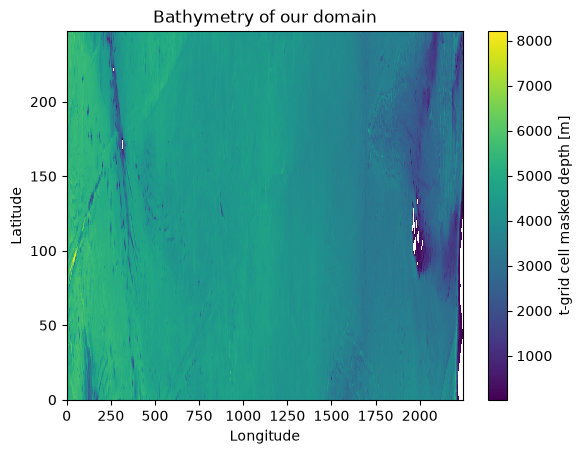

In [7]:
# To add a land mask to the domain, it's easy to just use the .where method to only plot the points where the bathymetry is not zero
expt.bathymetry.depth.where(expt.bathymetry.mask).plot()
plt.title("Bathymetry of our domain"), plt.xlabel("Longitude") , plt.ylabel("Latitude");

Next, we pass on the paths to the initial and boundary conditions. These are the GLORYS files that we downloaded earlier to our `tmp_dir`. 

Importantly, if you didn't want to force with GLORYS data, you'll need to modify the`ocean_varnames` dictionary that maps the MOM6 variable names (`yh`, `xh` etc.) to the variable names in the dataset. 

The last thing you need to do is specify which Arakawa grid your input data is on. In the case of the GLORYS dataset, tracers and velocities are on the same grid points, so it's an "A" grid. 

In [6]:
# Mapping dictionary between MOM6 variable names (left) and those in GLORYS (right), which is the source dataset for the forcing files
# If you use a different source dataset, simply replace the GLORYS names with those in your dataset of choice

ocean_varnames = {"time": "time",
                  "yh": "latitude", 
                  "xh": "longitude",
                  "zl": "depth",
                  "eta": "zos",
                  "u": "uo",
                  "v": "vo",
                  "tracers": {"salt": "so", "temp": "thetao"} # You can have as many tracers here as you like, and they will all get regridded to your ICs / BCs
                  }

# Set up the initial condition.
# expt.setup_initial_condition(
#     tmp_dir + "/ic_unprocessed.nc",
#     ocean_varnames,
#     arakawa_grid = "A"
#     )

# Set up the four boundary conditions.
expt.setup_ocean_state_boundaries(
    Path(tmp_dir),
    ocean_varnames,
    arakawa_grid = "A"
    )

Processing north boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


Done.
Processing south boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


Done.
Processing east boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


Done.
Processing west boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


Done.


Now we've made our initial and boundary conditions, these files are also now in our `input_dir`. The initial conditions can also be plotted via our experiment object. Remember that calling `expt.init_tracers` just returns an xarray object, so everything from there on is just xarray syntax

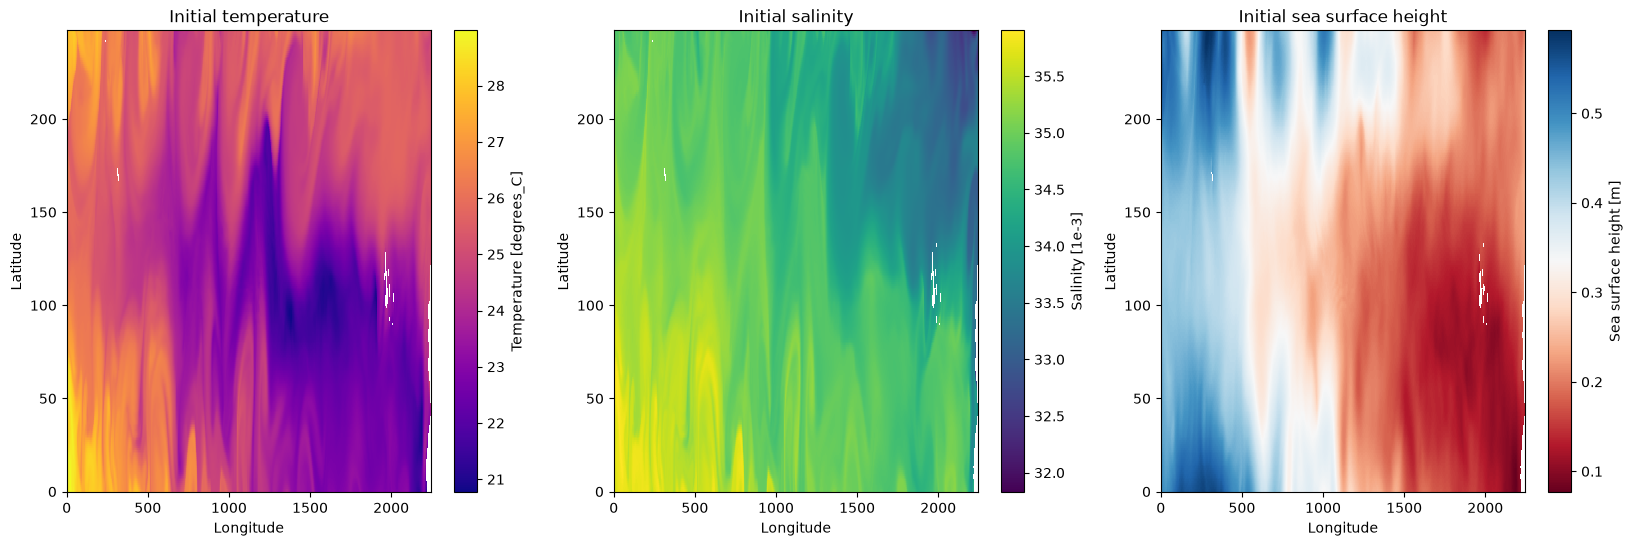

In [9]:
fig,ax = plt.subplots(1,3,figsize=(20, 6))
# Plot the surface values of temperature, salinity and sea surface height for the initial conditions
expt.init_tracers.temp.isel(zl = 0).where(expt.bathymetry.depth != 0).plot(ax=ax[0],cmap = "plasma")
expt.init_tracers.salt.isel(zl = 0).where(expt.bathymetry.depth != 0).plot(ax=ax[1])
expt.init_eta.eta_t.where(expt.bathymetry.depth != 0).plot(ax=ax[2],cmap = "RdBu")
ax[0].set_title("Initial temperature"), ax[1].set_title("Initial salinity"), ax[2].set_title("Initial sea surface height")
for i in ax:
    i.set_xlabel("Longitude"), i.set_ylabel("Latitude")

5. Set up the surface forcing

The last step is to set up the data atmosphere to use the ERA5 data product. Since the raw ERA5 data isn't in a suitable format to force an ocean model, `regional-mom6` pre-processes the raw data to create a data forcing product for your experiment. 

In [6]:
expt.setup_era5("/g/data/rt52/era5/single-levels/reanalysis/")

First I've manually cloned this repo to my run directory. Otherwise, setting overwrite=True below lets rmom6 do it for you

`git clone https://github.com/ACCESS-NRI/access-om3-configs.git -b M_regional_template`


**IMPORTANT**
The `overwrite` flag means business. If you set `overwrite=True`, then `regional-mom6` will delete everything in your run directory and re-clone from github. This doesn't affect files in your input directory (all the `.nc` files) but _will_ undo any manual edits you've made in your run directory. With `overwrite=False`, `regional-mom6` instead attempts to modify existing files.

In [11]:
expt.setup_rOM3(branch = "1463-M_regional_template",overwrite=False,mask_land_cpus=False,ncpus = 832)

Overwrite set to False. I'll attempt to modify existing files in the directory rather than replacing them entirely.
If any files are missing the run directory, you can get them from the template directory at https://github.com/ACCESS-NRI/access-om3-configs/tree/M_regional_template
ERA5 set to True - attempting to create an ESMF mesh for the surface forcing using
python3 /g/data/vk83/apps/om3-scripts/mesh_generation/generate_mesh.py --grid-type=latlon --grid-filename=/g/data/gb02/ab8992/rom3-inputdirs/nino-25th/10u_ERA5.nc --mesh-filename=/g/data/gb02/ab8992/rom3-inputdirs/nino-25th/era5-ESMF-mesh.nc --wrap-lons=True


Traceback (most recent call last):
  File "/containerised_envs/rmom6/dev-20260907T163942-10da054-pr34/lib/python3.14/site-packages/xarray/backends/file_manager.py", line 219, in _acquire_with_cache_info
    file = self._cache[self._key]
           ~~~~~~~~~~~^^^^^^^^^^^
  File "/containerised_envs/rmom6/dev-20260907T163942-10da054-pr34/lib/python3.14/site-packages/xarray/backends/lru_cache.py", line 56, in __getitem__
    value = self._cache[key]
            ~~~~~~~~~~~^^^^^
KeyError: [<class 'netCDF4._netCDF4.Dataset'>, ('/g/data/gb02/ab8992/rom3-inputdirs/nino-25th/10u_ERA5.nc',), 'r', (('clobber', True), ('diskless', False), ('format', 'NETCDF4'), ('persist', False)), '94bb07b4-66fd-41d8-ab7d-330593d55ef8']

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/g/data/vk83/apps/om3-scripts/mesh_generation/generate_mesh.py", line 605, in <module>
    main()
    ~~~~^^
  File "/g/data/vk83/apps/om3-scripts/mesh_generation/gene

## 6. Run with payu

This step takes place in a terminal on gadi inside your run directory. For further information about the `payu` workflow management tool, see the [documentation](https://payu.readthedocs.io/en/latest/)

1. load payu with

    `module use /g/data/vk83/modules; module load payu`

2. Set up the experiment:

    `payu setup`

2. Run the experiment

    `payu run -f`


# END OF ROM3 WORKFLOW. Coupled model stuff below

The first thing I'll do is define a slightly larger grid for the atmosphere for the ocean grid to sit inside of. The additional "buffer" is the same as the atmosphereic sponge layer. This is hardcoded to 7 grid points

ERA5 UM domain
SW corner:		 187.64 -7.36 
nx, ny  		 1182 182

Put these values into the ancil suite for the inner & ERA5 driving domains:
Inner UM domain
SW corner:		 189.23999999999998 -5.76 
nx, ny  		 1142 142



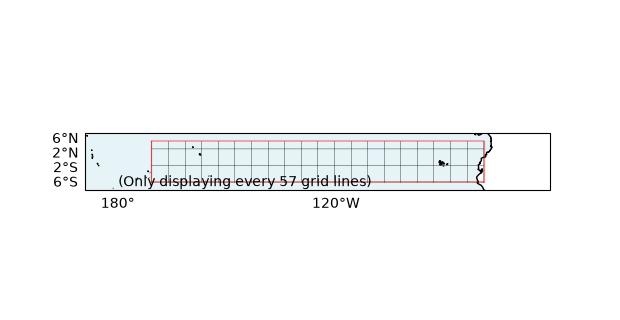

In [19]:
## Number of extra grid points that our atmosphere grid has so its sponge region doen't overlap with the ocean
dx_atm = 0.08
dy_atm = 0.08

# Based on the ocean grid, make the target lat/lon extents for the atm
# Rather than tha intended extents, use the actual extent that the ocean ended up with


target_lon_extent_atm = [expt.hgrid.x.values[0,1],expt.hgrid.x.values[0,-2]]
target_lat_extent_atm = [expt.hgrid.y.values[1,0],expt.hgrid.y.values[-2,0]]
xstart = round(target_lon_extent_atm[0],5)
ystart = round(target_lat_extent_atm[0],5)
lenx_atm = float(make_bounds(dx_atm,target_lon_extent_atm))
leny_atm = float(make_bounds(dy_atm,target_lat_extent_atm))


buffer_x = 20 * dx_atm
buffer_y = 20 * dy_atm
atm_grid = rmom6.Grid(
    lenx = lenx_atm + buffer_x,
    leny = leny_atm + buffer_y,
    xstart = xstart - buffer_x/2,
    ystart = ystart - buffer_y/2,
    nx = int(round((lenx_atm + buffer_x) / dx)),
    ny = int(round((leny_atm + buffer_y) / dy)),
    # resolution_lon = dx_atm,
    # resolution_lat = dy_atm
    )

atm_grid.write_supergrid(expt.mom_input_dir / "um_hgrid.nc")

# Now make the era5 grid. This isn't actually needed for anything - we
# just need to know how big it is and where its southwest corner is to
# feed to the ancil suite

# The buffer here should be at least 8 more points on either side to give the right sized sponge
# region to the UM. Lets make it 10 just to be sure
era5_buffer_x = 40 * dx_atm
era5_buffer_y = 40 * dy_atm
era5_atm_grid = rmom6.Grid(
    lenx = lenx_atm + buffer_x + era5_buffer_x,
    leny = leny_atm + buffer_y + era5_buffer_y,
    xstart = xstart - (era5_buffer_x + buffer_x)/2,
    ystart = ystart - (era5_buffer_y + buffer_y)/2,
    nx = int(round((lenx_atm + buffer_x + era5_buffer_x) / dx)),
    ny = int(round((leny_atm + buffer_y + era5_buffer_y) / dy)),
    )
era5_atm_grid.write_supergrid(expt.mom_input_dir / "era5_hgrid.nc")

print("ERA5 UM domain")
print(
    "SW corner:\t\t",
    era5_atm_grid.tlon.min().values - dx_atm/2,
    era5_atm_grid.tlat.min().values - dy_atm/2,
    "\nnx, ny  \t\t",
    era5_atm_grid.tlon.shape[1],
    era5_atm_grid.tlon.shape[0],
    )

print("\nPut these values into the ancil suite for the inner & ERA5 driving domains:")
print("Inner UM domain")
print(
    "SW corner:\t\t",
    atm_grid.tlon.min().values - dx_atm/2,
    atm_grid.tlat.min().values - dy_atm/2,
    "\nnx, ny  \t\t",
    atm_grid.tlon.shape[1],
    atm_grid.tlon.shape[0],end="\n\n"
    )

fig = atm_grid.plot()
fig.set_size_inches((6,3))

### Having produced an atmosphere grid, we now need to make a bathymetry file based on this slightly larger atm grid to feed to ancils

Rather than making a whole new experiment object, we will evoke the Topo and Grid objects directly to just do what we need.
The following code is exactly what regional-mom6 does under the hood within the `setup_bathymetry` method

In [20]:
import xarray as xr
atm_topo = rmom6.Topo(grid = atm_grid,min_depth = expt.minimum_depth,git = False)

atm_topo.set_from_dataset(
    bathymetry_path='/g/data/ik11/inputs/GEBCO_2022/GEBCO_2022.nc',
    output_dir=expt.mom_input_dir,
    longitude_coordinate_name='lon',
    latitude_coordinate_name='lat',
    vertical_coordinate_name='elevation',
    regridding_method=None,
    fill_channels=True,
    is_input_positive_below_msl=False,
    write_to_file=True,
    depth_method="xesmf",
    mask_method="dataset")

atm_topo.write_topo(expt.mom_input_dir / "um_bathymetry.nc")
atm_topo.write_esmf_mesh(expt.mom_input_dir / "um_ESMF_mesh.nc")

# Remove the mask - overwrite with mask free version
um_emsfmesh = xr.open_dataset(expt.mom_input_dir / "um_ESMF_mesh.nc")
um_emsfmesh.elementMask.values[:] = 0
um_emsfmesh.to_netcdf(expt.mom_input_dir / "um_ESMF_mesh.nc",mode = "w")

Slicing source bathymetry to domain: (189.23999999999998, 280.59999999999997) x (-5.76, 5.6) with buffer 0.5
  Resolution Diagnostics

  Source dataset (GEBCO_2022.nc):
    dlon = 15.0 arcsec  (0.004167°)
    dlat = 15.0 arcsec  (0.004167°)
    dx   ~ 461 m)
    dy   ~ 463 m

  Model grid (T-cell spacing):
    median = 8.89 km
    min    = 8.87 km
    max    = 8.90 km

  Resolution ratio (model dx / dataset dx):
    median = 19.3x
    max    = 19.3x

  Cressman / stats-mask threshold: 12x
  → RECOMMENDED: high_res_regrid()  (Cressman + stats mask)
    Each model cell spans ~19 dataset pixels per side.
    Ocean-aware Cressman interpolation will meaningfully reduce
    land contamination of coastal depth estimates.
Resolution diagnostics recommend using stats-based masking, but xesmf-based depth was requested, so we will do a direct xesmf regrid anyway because it was explicitly requested, but be aware that this may lead to significant land contamination of coastal depth estimates
**NOTE

PermissionError: [Errno 13] Permission denied: '/g/data/gb02/ab8992/rom3-inputdirs/nino-12th/um_ESMF_mesh.nc'

In [6]:
# Remove the mask - overwrite with mask free version
import xarray as xr
# um_emsfmesh = xr.open_dataset(expt.mom_input_dir / "um_ESMF_mesh.nc")
um_emsfmesh.elementMask.values[:] = 1
um_emsfmesh.to_netcdf(expt.mom_input_dir / "um_ESMF_mesh.nc",mode = "w")
um_emsfmesh.to_netcdf(expt.mom_input_dir / "um_ESMF_mesh.nc",mode = "w")


## Check the esmfmeshes

There's an issue where ESMF reckons our mesh isn't connected in 3 places or something. the ocean only case runs, let's figure out what the problem is with the um case

In [22]:
import xarray as xr

mom_mesh = xr.open_dataset(expt.mom_input_dir / "access-rom3-ESMFmesh.nc")
um_mesh = xr.open_dataset(expt.mom_input_dir / "um_ESMF_mesh.nc")

In [28]:
um_mesh.nodeCoords.values

array([[189.24,  -5.76],
       [189.32,  -5.76],
       [189.4 ,  -5.76],
       ...,
       [280.44,   5.6 ],
       [280.52,   5.6 ],
       [280.6 ,   5.6 ]], shape=(163449, 2))